## Proyecto Final — Minería de Datos  
## Clasificación de Diabetes · Pima Indians Dataset

In [31]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from scipy import stats
from scipy.stats import shapiro, spearmanr, pearsonr, chi2_contingency, mannwhitneyu
from scipy.spatial.distance import mahalanobis

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

---
## BLOQUE 1 — Estadística Descriptiva y Exploratoria
### Paso 1 · Cargar datos y revisar el diccionario de variables

In [32]:
df_train = pd.read_csv('Training.csv')
df_test  = pd.read_csv('Testing.csv')

print(f'Training : {df_train.shape[0]} filas x {df_train.shape[1]} columnas')
print(f'Testing  : {df_test.shape[0]}  filas x {df_test.shape[1]}  columnas')
df_train.head(8)

Training : 2460 filas x 9 columnas
Testing  : 308  filas x 9  columnas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6000,0.6270,50,1
1,1,85,66,29,0,26.6000,0.3510,31,0
2,8,183,64,0,0,23.3000,0.6720,32,1
3,1,89,66,23,94,28.1000,0.1670,21,0
4,0,137,40,35,168,43.1000,2.2880,33,1
5,5,116,74,0,0,25.6000,0.2010,30,0
6,3,78,50,32,88,31.0000,0.2480,26,1
7,10,115,0,0,0,35.3000,0.1340,29,0


In [33]:
# Diccionario de variables
diccionario = pd.DataFrame({
    'Variable'   : df_train.columns,
    'Rol'        : ['Input']*8 + ['Output'],
    'Tipo'       : ['Cuantitativa discreta', 'Cuantitativa continua', 'Cuantitativa continua',
                    'Cuantitativa continua', 'Cuantitativa continua', 'Cuantitativa continua',
                    'Cuantitativa continua', 'Cuantitativa discreta', 'Cualitativa binaria'],
    'Descripción': ['Número de embarazos', 'Nivel de Glucosa en sangre',
                    'Nivel de Presión arterial', 'Grosor de la piel(mm)',
                    'Nivel de insulina en Sangre', 'Índice de masa corporal',
                    'Porcentaje de diabetes', 'Edad (años)',
                    '0=Sin diabetes · 1=Con diabetes']
})
diccionario

,Variable,Rol,Tipo,Descripción
0,Pregnancies,Input,Cuantitativa discreta,Número de embarazos
1,Glucose,Input,Cuantitativa continua,Nivel de Glucosa en sangre
2,BloodPressure,Input,Cuantitativa continua,Nivel de Presión arterial
3,SkinThickness,Input,Cuantitativa continua,Grosor de la piel(mm)
4,Insulin,Input,Cuantitativa continua,Nivel de insulina en Sangre
5,BMI,Input,Cuantitativa continua,Índice de masa corporal
6,DiabetesPedigreeFunction,Input,Cuantitativa continua,Porcentaje de diabetes
7,Age,Input,Cuantitativa discreta,Edad (años)
8,Outcome,Output,Cualitativa binaria,0=Sin diabetes · 1=Con diabetes


In [34]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2460 non-null   int64  
 1   Glucose                   2460 non-null   int64  
 2   BloodPressure             2460 non-null   int64  
 3   SkinThickness             2460 non-null   int64  
 4   Insulin                   2460 non-null   int64  
 5   BMI                       2460 non-null   float64
 6   DiabetesPedigreeFunction  2460 non-null   float64
 7   Age                       2460 non-null   int64  
 8   Outcome                   2460 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 173.1 KB


### Paso 2 · Análisis Univariado
Media, mediana, moda, IQR, CV, asimetría y curtosis para cada variable.

In [35]:
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

stats_uni = pd.DataFrame(index=features)
stats_uni['Media']     = df_train[features].mean()
stats_uni['Mediana']   = df_train[features].median()
stats_uni['Moda']      = df_train[features].mode().iloc[0]
stats_uni['Q1']        = df_train[features].quantile(0.25)
stats_uni['Q3']        = df_train[features].quantile(0.75)
stats_uni['IQR']       = stats_uni['Q3'] - stats_uni['Q1']
stats_uni['CV (%)']    = (df_train[features].std() / df_train[features].mean() * 100).round(2)
stats_uni['Asimetría'] = df_train[features].skew()
stats_uni['Curtosis']  = df_train[features].kurtosis()

print('Estadística Univariada:')
stats_uni.style.background_gradient(cmap='Blues', subset=['Media','Mediana'])\
               .format('{:.3f}')

Estadística Univariada:


,Media,Mediana,Moda,Q1,Q3,IQR,CV (%),Asimetría,Curtosis
Pregnancies,3.817,3.000,1.000,1.000,6.000,5.000,86.350,0.962,0.583
Glucose,121.602,117.000,100.000,100.000,142.000,42.000,26.140,0.123,0.774
BloodPressure,68.915,70.000,70.000,64.000,80.000,16.000,27.690,-1.943,5.539
SkinThickness,20.531,23.000,0.000,0.000,33.000,33.000,76.550,-0.026,-1.166
Insulin,80.120,36.000,0.000,0.000,129.000,129.000,145.740,2.349,7.705
BMI,31.990,32.100,31.600,27.100,36.500,9.400,24.390,-0.364,3.036
DiabetesPedigreeFunction,0.491,0.381,0.254,0.252,0.647,0.395,74.050,2.151,6.431
Age,32.822,29.000,21.000,24.000,39.000,15.000,34.280,1.250,1.287


# CONCLUSIONES A PARTIR DE ESTA TABLA
1. Insulina: extremadamente variable → posibles outliers o pacientes muy distintos metabólicamente. Podriamos aplicar transformaciones
2. Hay pocos valores muy altos que están jalando la media hacia arriba, asimetria a la derecha.
3. Insulina esta fuertemente sesgada comparando la media con la mediana.
4. Insulina, diabetesPredigreeFuntio y BloodPressure hay presencia de valores extremos importantes (IQR alto + Curtosis alta = outliers)
5. Glucose es la variable más equilibrada ( Baja asimetría, Media ≈ mediana, CV moderado)

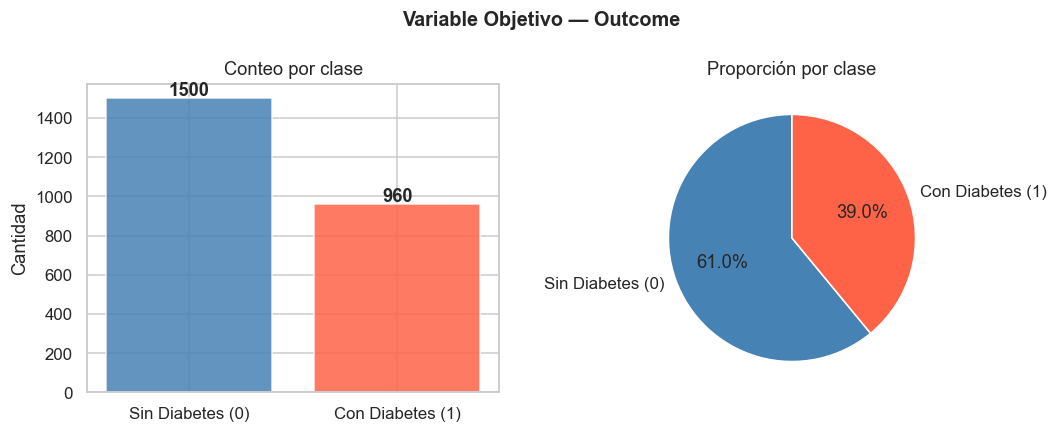

In [36]:
# Distribución de la variable objetivo
conteo = df_train['Outcome'].value_counts()
labels = ['Sin Diabetes (0)', 'Con Diabetes (1)']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, conteo, color=['steelblue','tomato'], alpha=0.85)
axes[0].set_title('Conteo por clase')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(conteo):
    axes[0].text(i, v+15, str(v), ha='center', fontweight='bold')
axes[1].pie(conteo, labels=labels, autopct='%1.1f%%',
            colors=['steelblue','tomato'], startangle=90)
axes[1].set_title('Proporción por clase')
plt.suptitle('Variable Objetivo — Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Paso 3 · Visualización Exploratoria
Histogramas y boxplots para cuantitativas; el pie plot para la variable objetivo ya fue mostrado.

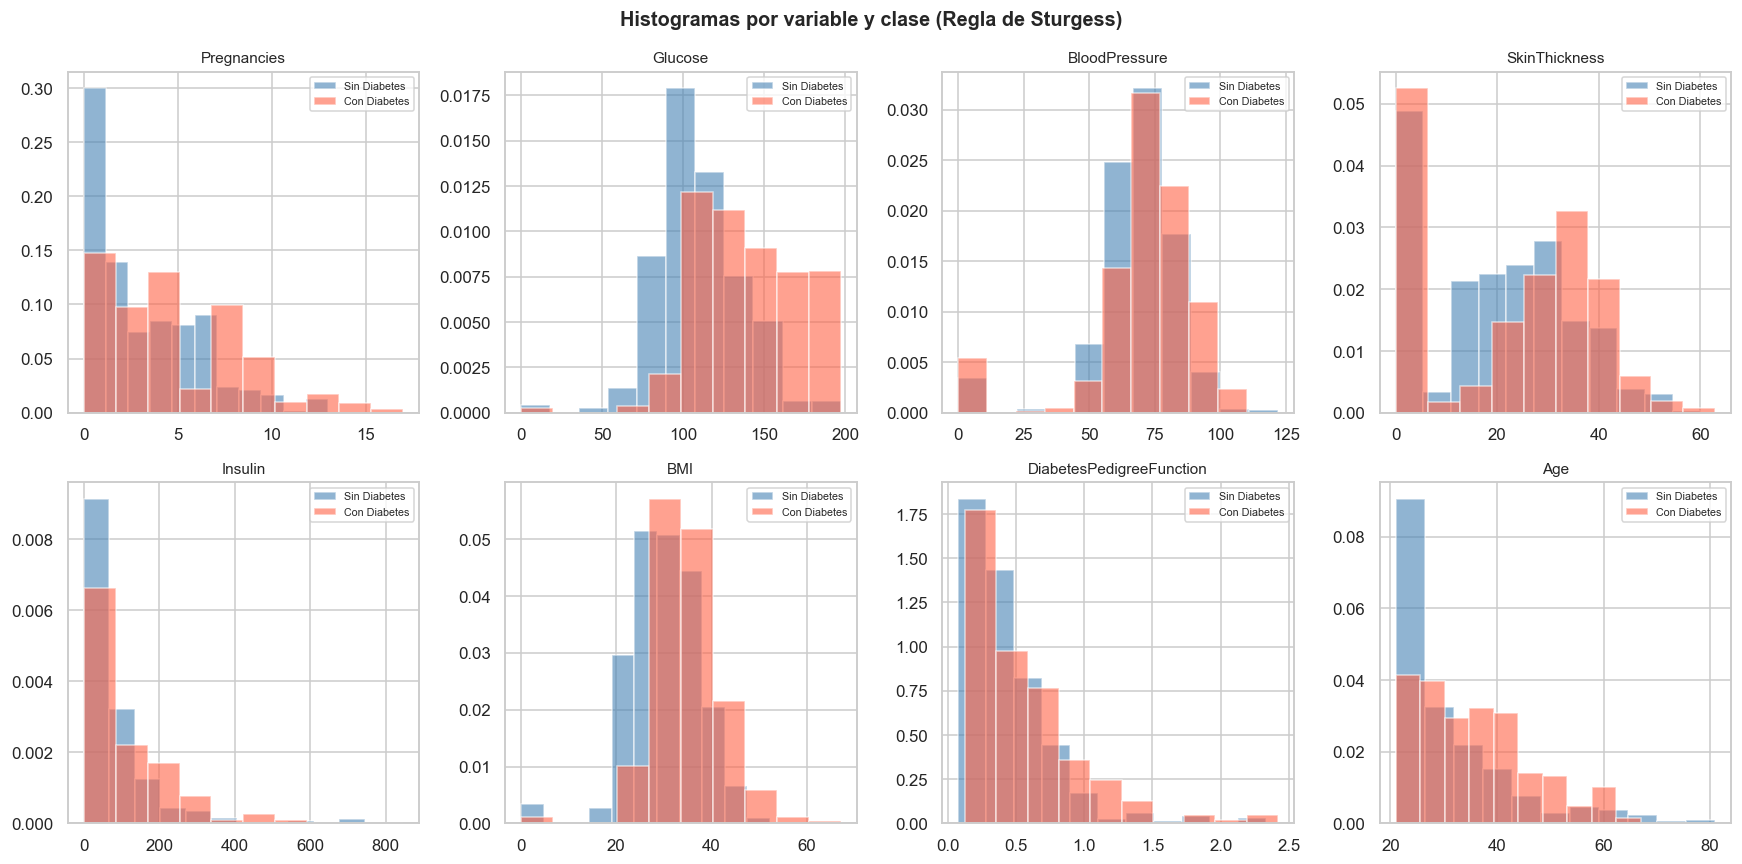

In [37]:
# Histogramas por variable y clase
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), features):
    for val, color, label in [(0,'steelblue','Sin Diabetes'), (1,'tomato','Con Diabetes')]:
        datos = df_train[df_train['Outcome']==val][col]
        n_bins = int(1 + 3.322 * np.log10(len(datos)))  # Regla de Sturgess
        ax.hist(datos, bins=n_bins, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Histogramas por variable y clase (Regla de Sturgess)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis bivariado evidencia que la variable Glucose presenta la mayor capacidad discriminativa entre individuos con y sin diabetes, seguida por BMI y Age, que muestran desplazamientos consistentes hacia valores más altos en la clase positiva. En contraste, variables como BloodPressure y SkinThickness exhiben un alto grado de solapamiento entre clases, lo que sugiere baja relevancia predictiva. Asimismo, la presencia de valores atípicos y concentraciones en cero en variables como Insulin y SkinThickness indica posibles problemas de calidad de datos, lo que requiere tratamiento previo antes de su inclusión en modelos predictivos.

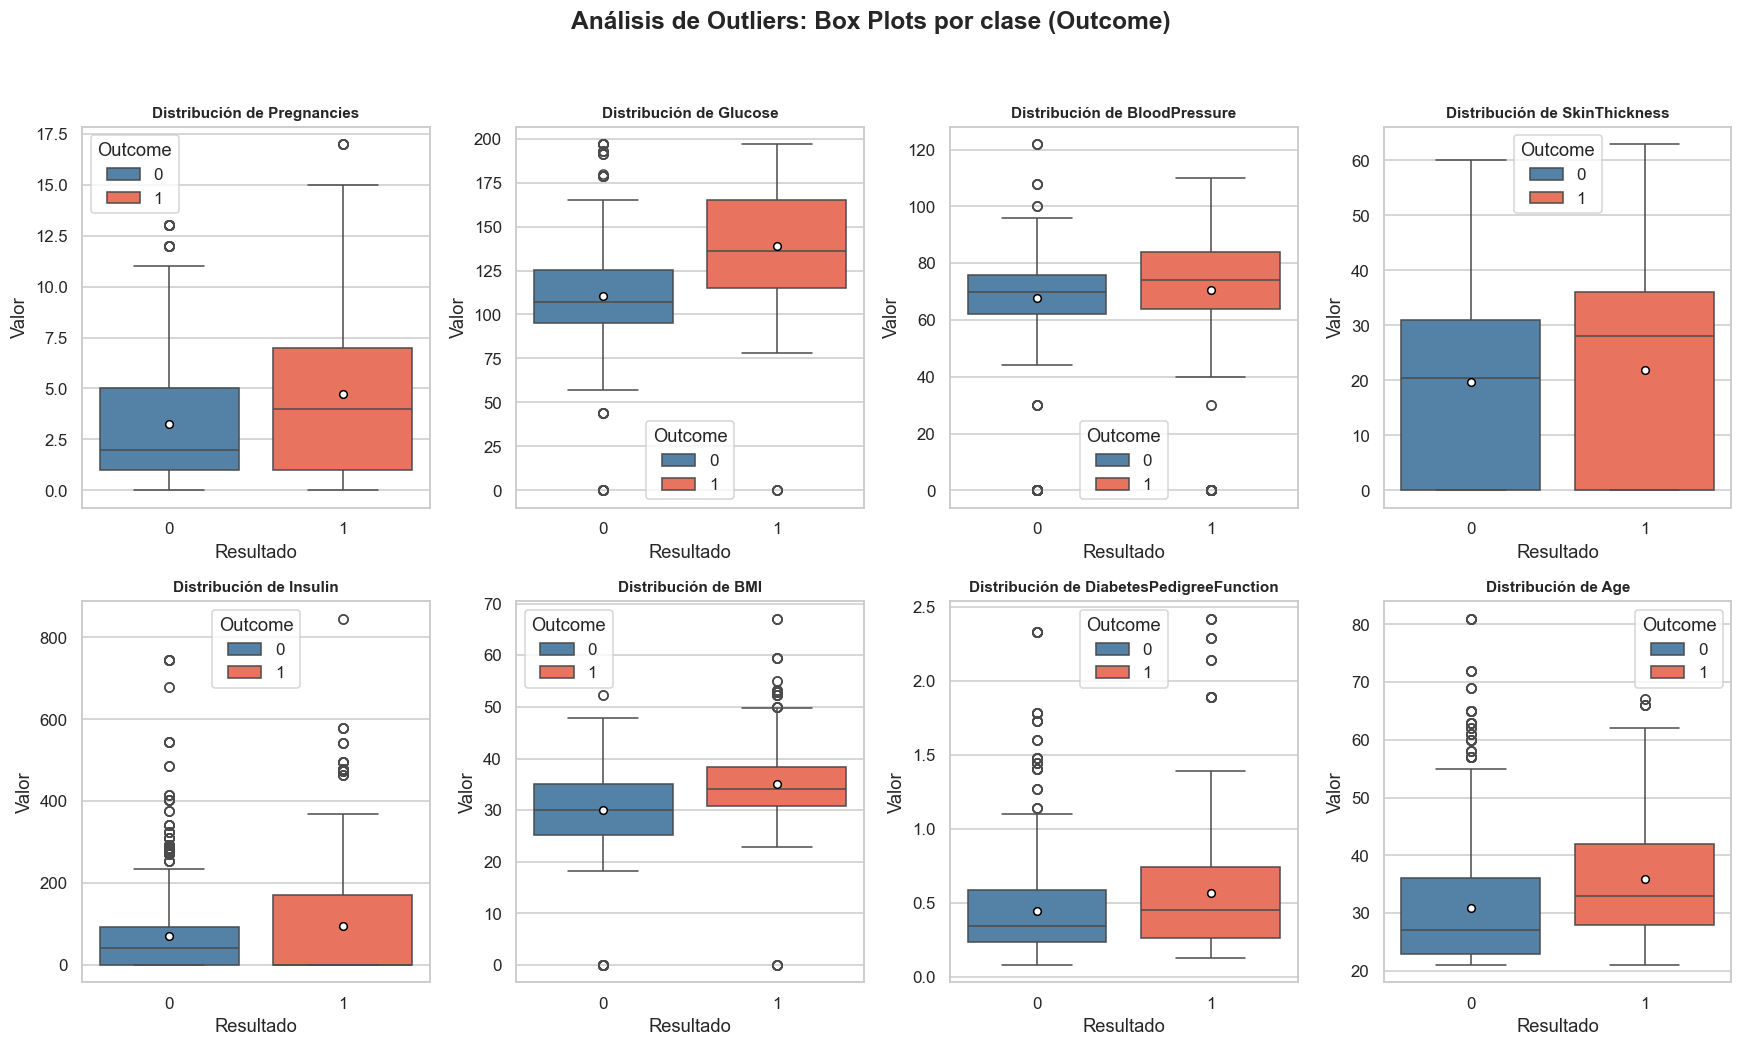

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos la paleta (incluimos números y strings para evitar errores de tipo de dato)
custom_palette = {0: 'steelblue', 1: 'tomato', '0': 'steelblue', '1': 'tomato'}

# Configuración de la figura: 2 filas y 4 columnas
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

for ax, col in zip(axes.flatten(), features):
    sns.boxplot(
        data=df_train, 
        x='Outcome', 
        y=col, 
        hue='Outcome',      # Define el color según la clase
        ax=ax,
        palette=custom_palette,
        showmeans=True,     # Muestra un punto para la media (opcional pero útil)
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"}
    )
    
    # Estética de cada subgráfico
    ax.set_title(f'Distribución de {col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Resultado')
    ax.set_ylabel('Valor')

# Título principal
plt.suptitle('Análisis de Outliers: Box Plots por clase (Outcome)', fontsize=16, fontweight='bold')

# Ajustar espacio para que no se amontonen las etiquetas
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Paso 4 · Prueba de Normalidad — Shapiro-Wilk (REGISTROS = 2460)
Determina si cada variable sigue distribución normal para elegir la prueba bivariada correcta según el tipo de comparación.

> **H₀:** la variable se aproxima a distribución normal  
> **p-valor < 5%** → Rechazar H₀ → Variable **NO** es normal  
> **p-valor ≥ 5%** → No rechazar H₀ → Variable **ES** normal  

| Comparación | Normal | No Normal |
|---|---|---|
| Feature vs Feature (multicolinealidad) | Pearson | Spearman |
| Feature vs **Target binario** (Outcome) | Point-Biserial | **Mann-Whitney U** |

> Dado que `Outcome` es una variable **binaria (0/1)**, la comparación correcta con cada feature numérica es **numérica vs categórica**, no numérica vs numérica. Por eso se usa Mann-Whitney U (no Spearman) para medir la relación con el target.

In [39]:
import pandas as pd
from scipy.stats import shapiro

ALPHA = 0.05
resultados_norm = []

for col in features:
    muestra = df_train[col].dropna().sample(min(2000, len(df_train)), random_state=42)
    stat, p = shapiro(muestra)

    if p > ALPHA:
        prueba_feat_feat   = 'Pearson'
        prueba_vs_target   = 'Point-Biserial'
    else:
        prueba_feat_feat   = 'Spearman'
        prueba_vs_target   = 'Mann-Whitney U'

    resultados_norm.append({
        'Variable'              : col,
        'Estadístico'           : round(stat, 4),
        'p-valor'               : round(p, 4),
        'Normal?'               : 'SÍ' if p > ALPHA else 'NO',
        'Feat vs Feat'          : prueba_feat_feat,
        'Feat vs Target binario': prueba_vs_target
    })

df_norm = pd.DataFrame(resultados_norm).set_index('Variable')

df_norm.style.map(
    lambda v: 'color:green;font-weight:bold' if v == 'SÍ'
    else ('color:red;font-weight:bold' if v == 'NO' else ''),
    subset=['Normal?']
)

,Estadístico,p-valor,Normal?,Feat vs Feat,Feat vs Target binario
Variable,,,,,
Pregnancies,0.906800,0.000000,NO,Spearman,Mann-Whitney U
Glucose,0.967200,0.000000,NO,Spearman,Mann-Whitney U
BloodPressure,0.806000,0.000000,NO,Spearman,Mann-Whitney U
SkinThickness,0.907100,0.000000,NO,Spearman,Mann-Whitney U
Insulin,0.713300,0.000000,NO,Spearman,Mann-Whitney U
BMI,0.954200,0.000000,NO,Spearman,Mann-Whitney U
DiabetesPedigreeFunction,0.810000,0.000000,NO,Spearman,Mann-Whitney U
Age,0.872400,0.000000,NO,Spearman,Mann-Whitney U


### Paso 5 · Análisis Bivariado

El análisis bivariado se divide en dos partes con objetivos distintos:

**5a — Heatmap Spearman entre features (multicolinealidad)**  
Detecta si dos predictores están altamente correlacionados entre sí. Se usa Spearman porque ninguna variable es normal (resultado del Paso 4).  
> Correlaciones altas entre features (|r| > 0.7) pueden causar redundancia en el modelo.

**5b — Mann-Whitney U: cada feature vs Outcome (target binario)**  
Compara la distribución de cada variable numérica entre los dos grupos (diabético / no diabético).  
Es el método correcto porque: variables **no normales** + target **binario** → Mann-Whitney U.  
Se complementa con el **rank-biserial (r)** como tamaño de efecto:

| r | Interpretación |
|---|---|
| < 0.1 | Efecto pequeño |
| 0.1 – 0.3 | Efecto moderado |
| ≥ 0.3 | Efecto grande |

> Con n = 2 460, casi todo resultará estadísticamente significativo. El **r** es lo que indica qué variables realmente discriminan entre clases.

> **p-valor < 5%** → distribuciones distintas entre clases → variable relevante para el target

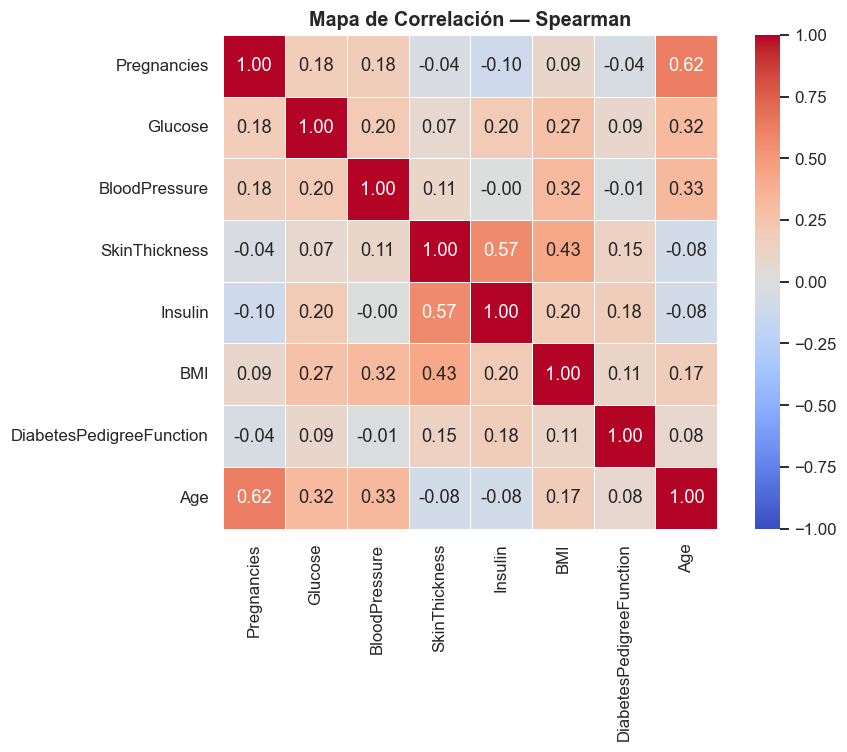

In [40]:
# Mapa de correlación (Spearman, ya que la mayoría no es normal)
corr_spearman = df_train[features].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Mapa de Correlación — Spearman', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

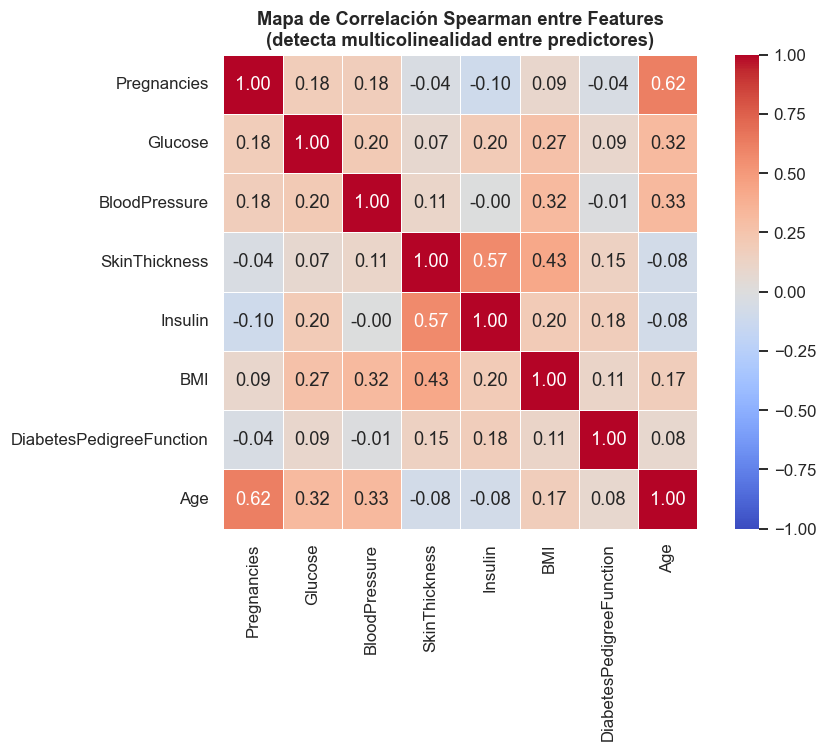

,U statistic,p-valor,Significativa?,r (efecto),Tamaño efecto
Variable,,,,,
Glucose,336441.500000,0.000000,SÍ ✔,0.532700,Grande
BMI,452389.500000,0.000000,SÍ ✔,0.371700,Grande
Age,466726.000000,0.000000,SÍ ✔,0.351800,Grande
Pregnancies,560266.500000,0.000000,SÍ ✔,0.221900,Moderado
DiabetesPedigreeFunction,574536.000000,0.000000,SÍ ✔,0.202000,Moderado
BloodPressure,592136.500000,0.000000,SÍ ✔,0.177600,Moderado
SkinThickness,639815.500000,0.000000,SÍ ✔,0.111400,Moderado
Insulin,672161.000000,0.003160,SÍ ✔,0.066400,Pequeño


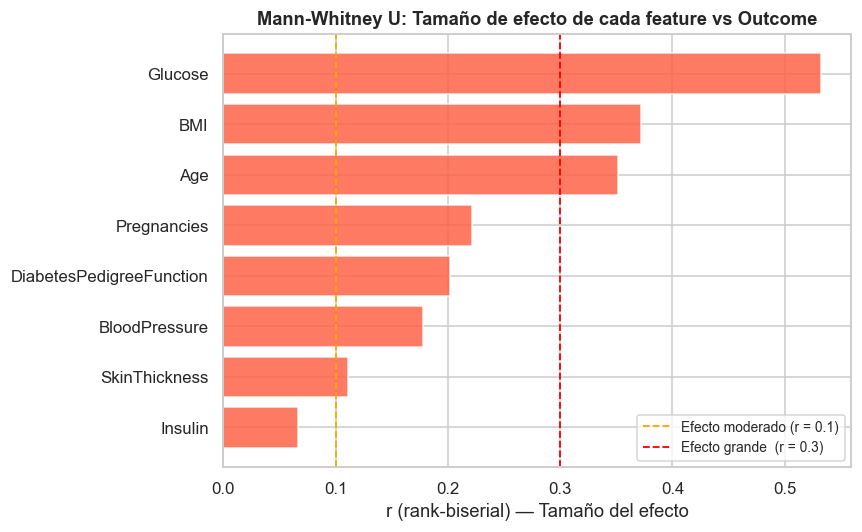

In [41]:
# ── 5a: Heatmap Spearman entre features (multicolinealidad) ───────────────────
corr_spearman = df_train[features].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Mapa de Correlación Spearman entre Features\n(detecta multicolinealidad entre predictores)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5b: Mann-Whitney U — Feature numérica vs Outcome binario ──────────────────
resultados_mw = []
for col in features:
    grupo0 = df_train[df_train['Outcome'] == 0][col]
    grupo1 = df_train[df_train['Outcome'] == 1][col]
    stat, p = mannwhitneyu(grupo0, grupo1, alternative='two-sided')
    n0, n1  = len(grupo0), len(grupo1)
    r       = abs(1 - (2 * stat) / (n0 * n1))   # rank-biserial (tamaño de efecto)
    efecto  = 'Grande' if r >= 0.3 else ('Moderado' if r >= 0.1 else 'Pequeño')
    resultados_mw.append({
        'Variable'      : col,
        'U statistic'   : round(stat, 2),
        'p-valor'       : round(p, 5),
        'Significativa?': 'SÍ ✔' if p < ALPHA else 'NO ✘',
        'r (efecto)'    : round(r, 4),
        'Tamaño efecto' : efecto
    })

df_mw = pd.DataFrame(resultados_mw).set_index('Variable')\
          .sort_values('r (efecto)', ascending=False)

display(df_mw.style.map(
    lambda v: 'color:green;font-weight:bold' if v == 'SÍ ✔'
    else ('color:red;font-weight:bold' if v == 'NO ✘' else ''),
    subset=['Significativa?']
))

# Gráfico de tamaño de efecto (rank-biserial)
df_plot  = df_mw.sort_values('r (efecto)')
colores  = ['tomato' if v == 'SÍ ✔' else 'lightgray' for v in df_plot['Significativa?']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_plot.index, df_plot['r (efecto)'], color=colores, alpha=0.85)
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1.2, label='Efecto moderado (r = 0.1)')
ax.axvline(0.3, color='red',    linestyle='--', linewidth=1.2, label='Efecto grande  (r = 0.3)')
ax.set_xlabel('r (rank-biserial) — Tamaño del efecto')
ax.set_title('Mann-Whitney U: Tamaño de efecto de cada feature vs Outcome',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## BLOQUE 2 — Identificación y Tratamiento de Valores Faltantes
### Paso 6 · Identificar tipo de dato faltante y tratar
Las columnas `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI` contienen **ceros biológicamente imposibles** → se tratan como NaN.

| % Faltantes | Impacto | Acción sugerida |
|---|---|---|
| < 1% | Trivial | Eliminar o imputar |
| 1% – 5% | Manejable | Imputar (media/mediana) |
| 5% – 15% | Requiere métodos sofisticados | KNN, regresión múltiple |
| > 15% | Interpretación perjudicial | Analizar causa raíz |

In [42]:
df_train.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [43]:
cols_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Reporte de ceros (faltantes encubiertos)
reporte = []
for col in cols_ceros:
    n = (df_train[col] == 0).sum()
    pct = n / len(df_train) * 100
    if pct < 1:
        accion = 'Imputar (< 1% → trivial)'
    elif pct <= 5:
        accion = 'Imputar por mediana de clase'
    elif pct <= 15:
        accion = 'Imputar por mediana de clase (moderado)'
    else:
        accion = '⚠ Crítico → imputar por mediana de clase + documentar'
    reporte.append({'Variable': col, 'Ceros': n, '% Faltante': round(pct, 2), 'Acción': accion})

pd.DataFrame(reporte).set_index('Variable')

,Ceros,% Faltante,Acción
Variable,,,
Glucose,17,0.6900,Imputar (< 1% → trivial)
BloodPressure,114,4.6300,Imputar por mediana de clase
SkinThickness,717,29.1500,⚠ Crítico → imputar por mediana de clase + doc...
Insulin,1181,48.0100,⚠ Crítico → imputar por mediana de clase + doc...
BMI,31,1.2600,Imputar por mediana de clase


In [44]:
def reemplazar_ceros_por_nan(df, columnas):
    df = df.copy()
    df[columnas] = df[columnas].replace(0, np.nan)
    return df

def imputar_por_mediana_clase(df_in, df_ref, columnas, target='Outcome'):
    """Imputa NaN con la mediana de cada clase calculada en df_ref (evita data leakage)."""
    df = df_in.copy()
    for col in columnas:
        medianas = df_ref.groupby(target)[col].median()
        for clase, mediana in medianas.items():
            mask = df['Outcome'] == clase
            df.loc[mask & df[col].isna(), col] = mediana
        # Si quedan NaN (clase sin mediana en ref), usar mediana global de ref
        df[col] = df[col].fillna(df_ref[col].median())
    return df

df_train_c = reemplazar_ceros_por_nan(df_train, cols_ceros)
df_test_c  = reemplazar_ceros_por_nan(df_test,  cols_ceros)

df_train_c = imputar_por_mediana_clase(df_train_c, df_train_c, cols_ceros)
df_test_c  = imputar_por_mediana_clase(df_test_c,  df_train_c, cols_ceros)  # ref = train

print('Nulos restantes — Train:', df_train_c.isnull().sum().sum())
print('Nulos restantes — Test :', df_test_c.isnull().sum().sum())

Nulos restantes — Train: 0
Nulos restantes — Test : 0


---
## BLOQUE 3 — Identificación y Tratamiento de Outliers
### Paso 7 · Detectar outliers univariados
Flujo: **Shapiro-Wilk** → si normal: regla **k=2 o k=3** → si NO normal: regla **Q1−3×IQR / Q3+3×IQR**

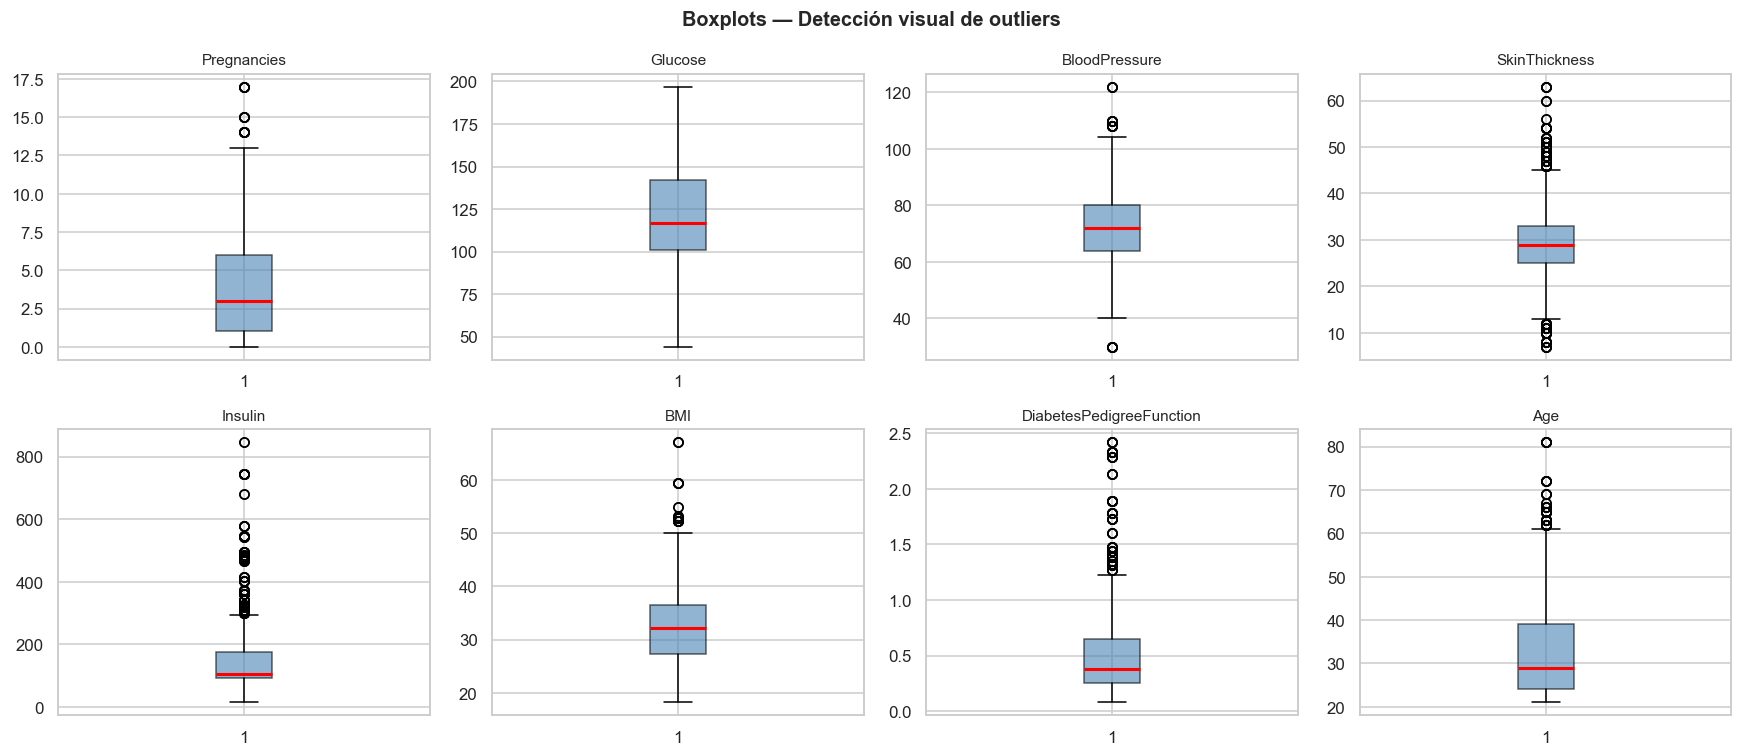

In [45]:
# Boxplots para detección visual
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), features):
    ax.boxplot(df_train_c[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=10)
plt.suptitle('Boxplots — Detección visual de outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# Conteo de outliers según criterio de la guía
reporte_out = []
for col in features:
    serie = df_train_c[col]
    _, p_sw = shapiro(serie.sample(min(2000, len(serie)), random_state=42))
    es_normal = p_sw > ALPHA

    if es_normal:
        mu, s = serie.mean(), serie.std()
        k = 3
        mask = (np.abs(serie - mu) / s) > k
        criterio = f'Normal → |z| > {k}'
    else:
        Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
        IQR = Q3 - Q1
        mask = (serie < Q1 - 3*IQR) | (serie > Q3 + 3*IQR)
        criterio = 'NO Normal → IQR×3'

    reporte_out.append({
        'Variable' : col,
        'Normal?'  : 'SÍ' if es_normal else 'NO',
        'Criterio' : criterio,
        'Outliers' : mask.sum(),
        '% del total': round(mask.sum()/len(serie)*100, 2)
    })

df_out = pd.DataFrame(reporte_out).set_index('Variable')
df_out

,Normal?,Criterio,Outliers,% del total
Variable,,,,
Pregnancies,NO,NO Normal → IQR×3,0,0.0000
Glucose,NO,NO Normal → IQR×3,0,0.0000
BloodPressure,NO,NO Normal → IQR×3,0,0.0000
SkinThickness,NO,NO Normal → IQR×3,8,0.3300
Insulin,NO,NO Normal → IQR×3,54,2.2000
BMI,NO,NO Normal → IQR×3,3,0.1200
DiabetesPedigreeFunction,NO,NO Normal → IQR×3,35,1.4200
Age,NO,NO Normal → IQR×3,0,0.0000


### Paso 8 · Outliers multivariados — Distancia de Mahalanobis
Detecta outliers considerando la interacción entre múltiples variables a la vez.

Umbral Mahalanobis (chi² 97.5%): 4.187
Outliers multivariados detectados: 182 (7.40%)


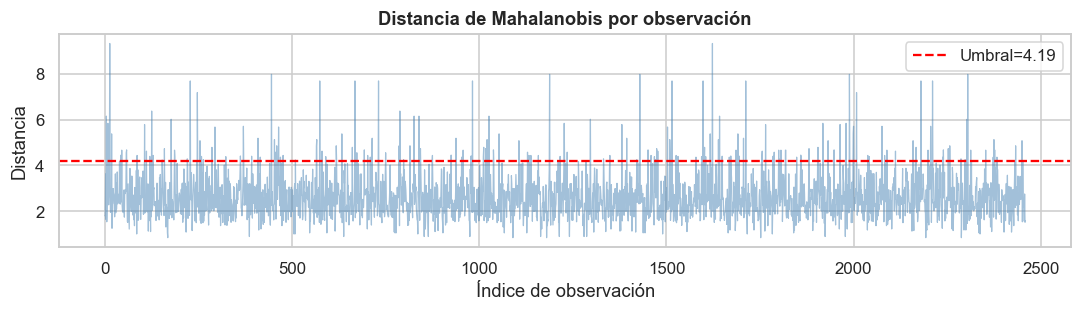

In [47]:
X_mah = df_train_c[features].values
media_vec = np.mean(X_mah, axis=0)
cov_matrix = np.cov(X_mah, rowvar=False)
inv_cov = np.linalg.inv(cov_matrix)

dist_mah = np.array([mahalanobis(x, media_vec, inv_cov) for x in X_mah])

# Umbral: chi² con k grados de libertad al 97.5%
umbral_mah = np.sqrt(stats.chi2.ppf(0.975, df=len(features)))
outliers_mah = (dist_mah > umbral_mah).sum()

print(f'Umbral Mahalanobis (chi² 97.5%): {umbral_mah:.3f}')
print(f'Outliers multivariados detectados: {outliers_mah} ({outliers_mah/len(df_train_c)*100:.2f}%)')

plt.figure(figsize=(10, 3))
plt.plot(dist_mah, alpha=0.5, linewidth=0.8, color='steelblue')
plt.axhline(umbral_mah, color='red', linestyle='--', label=f'Umbral={umbral_mah:.2f}')
plt.title('Distancia de Mahalanobis por observación', fontsize=12, fontweight='bold')
plt.xlabel('Índice de observación')
plt.ylabel('Distancia')
plt.legend()
plt.tight_layout()
plt.show()

### Paso 9 · Tratar outliers
Los outliers detectados son **valores reales** (no errores de captura), representan menos del 5%. Se aplica **Winsorizing (capping)** con IQR×3 — método seguro que no elimina filas.

> **Regla clave:** nunca eliminar un outlier sin verificar que sea un error real.

In [48]:
def winsorizing_iqr(df, columnas, factor=3.0):
    """Recorta valores extremos al límite inferior/superior de IQR×factor."""
    df = df.copy()
    for col in columnas:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1 - factor*IQR, upper=Q3 + factor*IQR)
    return df

df_train_c = winsorizing_iqr(df_train_c, features)
df_test_c  = winsorizing_iqr(df_test_c,  features)

print('Winsorizing IQR×3 aplicado. Verificación rápida de rangos:')
df_train_c[features].agg(['min','max']).T

Winsorizing IQR×3 aplicado. Verificación rápida de rangos:


,min,max
Pregnancies,0.0000,17.0000
Glucose,44.0000,197.0000
BloodPressure,30.0000,122.0000
SkinThickness,7.0000,57.0000
Insulin,14.0000,424.0000
BMI,18.2000,63.8000
DiabetesPedigreeFunction,0.0780,1.8328
Age,21.0000,81.0000


---
## BLOQUE 4 — Transformación y Escalado
### Paso 10 · Transformar distribuciones sesgadas
Si **Asimetría > 0** (cola derecha) → aplicar `log1p`, raíz cuadrada o Box-Cox.

In [49]:
# Columnas con sesgo positivo significativo (As > 1)
asimetria = df_train_c[features].skew()
cols_sesgadas = asimetria[asimetria > 1].index.tolist()
print('Variables con sesgo positivo > 1:', cols_sesgadas)
print(asimetria.sort_values(ascending=False).to_string())

Variables con sesgo positivo > 1: ['Insulin', 'DiabetesPedigreeFunction', 'Age']
DiabetesPedigreeFunction   1.7131
Insulin                    1.5964
Age                        1.2502
Pregnancies                0.9615
BMI                        0.5204
Glucose                    0.5180
BloodPressure              0.2037
SkinThickness              0.0814


In [50]:
# Aplicar log1p a variables con As > 1
df_train_t = df_train_c.copy()
df_test_t  = df_test_c.copy()

for col in cols_sesgadas:
    df_train_t[col] = np.log1p(df_train_t[col])
    df_test_t[col]  = np.log1p(df_test_t[col])

# Comparar asimetría antes y después
comparacion = pd.DataFrame({
    'As. antes': df_train_c[features].skew().round(3),
    'As. después': df_train_t[features].skew().round(3)
})
comparacion['Mejoró?'] = comparacion.apply(
    lambda r: 'SÍ ✔' if abs(r['As. después']) < abs(r['As. antes']) else '—', axis=1)
comparacion

,As. antes,As. después,Mejoró?
Pregnancies,0.9620,0.9620,—
Glucose,0.5180,0.5180,—
BloodPressure,0.2040,0.2040,—
SkinThickness,0.0810,0.0810,—
Insulin,1.5960,-0.1980,SÍ ✔
BMI,0.5200,0.5200,—
DiabetesPedigreeFunction,1.7130,1.0870,SÍ ✔
Age,1.2500,0.6520,SÍ ✔


### Paso 11 · Escalar variables numéricas
Como existen outliers → se usa **RobustScaler** (usa mediana e IQR, inmune a valores extremos).

> **Regla de oro:** Si dudas qué escalador usar → usa RobustScaler.

In [51]:
X_train = df_train_t[features]
y_train = df_train_t['Outcome']
X_test  = df_test_t[features]
y_test  = df_test_t['Outcome']

scaler = RobustScaler()                     # RobustScaler → hay outliers (guía paso 11)
X_train_sc = scaler.fit_transform(X_train)  # fit solo en train
X_test_sc  = scaler.transform(X_test)       # transform en test

X_train_sc = pd.DataFrame(X_train_sc, columns=features)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=features)

print('Escalado completado. Media post-escalado (≈0):')
print(X_train_sc.mean().round(3).to_string())

Escalado completado. Media post-escalado (≈0):
Pregnancies                0.1630
Glucose                    0.1320
BloodPressure              0.0160
SkinThickness              0.0200
Insulin                    0.1990
BMI                        0.0200
DiabetesPedigreeFunction   0.1870
Age                        0.1530


---
## BLOQUE 5 — Discretización
### Paso 12 · Discretizar variables de interés clínico
Con outliers → **Equal Frequency (pd.qcut)** — se adapta a la distribución real.

In [52]:
disc = df_train_c.copy()  # usar datos sin escalar para interpretabilidad

disc['Glucose.cat'] = pd.qcut(
    disc['Glucose'], q=3,
    labels=['Baja', 'Normal', 'Alta']
)
disc['BMI.cat'] = pd.qcut(
    disc['BMI'], q=3,
    labels=['Bajo', 'Normal', 'Alto']
)
disc['Age.cat'] = pd.qcut(
    disc['Age'], q=3,
    labels=['Joven', 'Adulto', 'Mayor']
)

print('Variables discretizadas:')
display(disc[['Glucose','Glucose.cat','BMI','BMI.cat','Age','Age.cat']].head(8))

Variables discretizadas:


,Glucose,Glucose.cat,BMI,BMI.cat,Age,Age.cat
0,148.0000,Alta,33.6000,Normal,50,Mayor
1,85.0000,Baja,26.6000,Bajo,31,Adulto
2,183.0000,Alta,23.3000,Bajo,32,Adulto
3,89.0000,Baja,28.1000,Bajo,21,Joven
4,137.0000,Alta,43.1000,Alto,33,Adulto
5,116.0000,Normal,25.6000,Bajo,30,Adulto
6,78.0000,Baja,31.0000,Normal,26,Adulto
7,115.0000,Normal,35.3000,Alto,29,Adulto


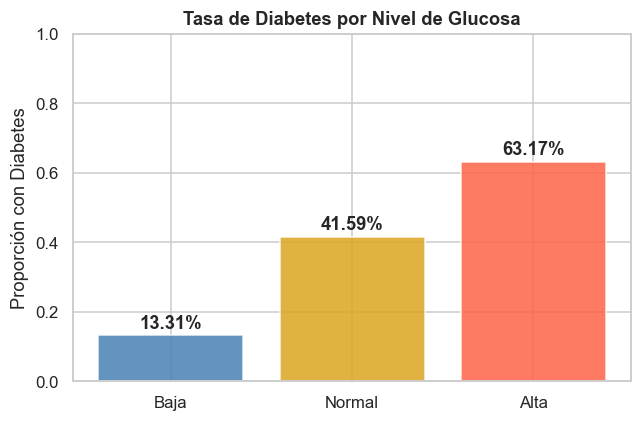

In [53]:
# Tasa de diabetes por categoría de glucosa
tasa = disc.groupby('Glucose.cat')['Outcome'].mean().reset_index()
tasa.columns = ['Glucosa', 'Tasa de Diabetes']

plt.figure(figsize=(6, 4))
plt.bar(tasa['Glucosa'].astype(str), tasa['Tasa de Diabetes'],
        color=['steelblue','goldenrod','tomato'], alpha=0.85)
plt.title('Tasa de Diabetes por Nivel de Glucosa', fontsize=12, fontweight='bold')
plt.ylabel('Proporción con Diabetes')
plt.ylim(0, 1)
for i, v in enumerate(tasa['Tasa de Diabetes']):
    plt.text(i, v+0.02, f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Paso 13 · Verificación — Dataset listo para modelado

In [54]:
checks = {
    'Sin valores nulos (train)' : X_train_sc.isnull().sum().sum() == 0,
    'Sin valores nulos (test)'  : X_test_sc.isnull().sum().sum() == 0,
    'Escalado aplicado'         : True,
    'Outliers tratados (IQR×3)' : True,
    'Distribuciones transformadas': True,
    'Forma train X'             : X_train_sc.shape,
    'Forma test X'              : X_test_sc.shape,
}
for k, v in checks.items():
    estado = '✔' if v is True else ('✘' if v is False else '')
    print(f'  {estado}  {k}: {v}')

    Sin valores nulos (train): True
    Sin valores nulos (test): True
  ✔  Escalado aplicado: True
  ✔  Outliers tratados (IQR×3): True
  ✔  Distribuciones transformadas: True
    Forma train X: (2460, 8)
    Forma test X: (308, 8)


---
## Modelado · Entrenamiento de clasificadores

In [55]:
modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión'  : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42),
    'KNN (k=7)'          : KNeighborsClassifier(n_neighbors=7),
}

resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    resultados.append({
        'Modelo'    : nombre,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'ROC-AUC'   : roc_auc_score(y_test, y_prob),
    })

df_res = pd.DataFrame(resultados).set_index('Modelo')
df_res.round(4).style.highlight_max(color='lightgreen', axis=0)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.850600,0.732700,0.795700,0.762900,0.908800
Árbol de Decisión,0.876600,0.809000,0.774200,0.791200,0.885600
Random Forest,0.899400,0.829800,0.838700,0.834200,0.957700
KNN (k=7),0.818200,0.676200,0.763400,0.717200,0.860000


## Evaluación · Comparación visual de modelos

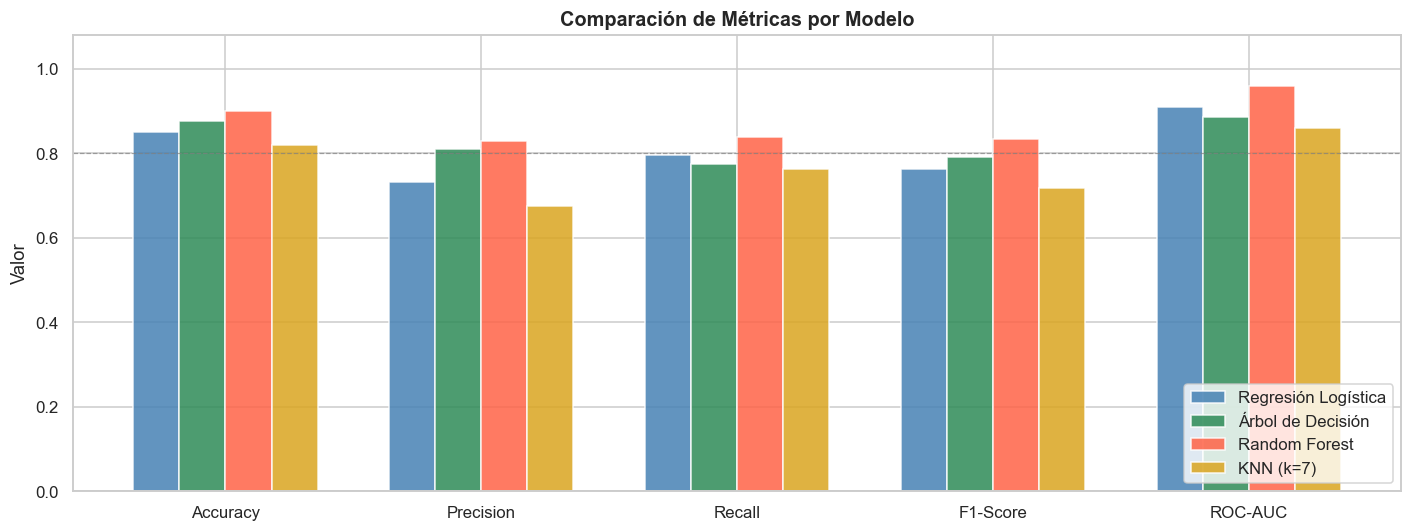

In [56]:
# Gráfico de barras comparativo
metricas = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(metricas))
width = 0.18
colors = ['steelblue','seagreen','tomato','goldenrod']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (nombre, row) in enumerate(df_res[metricas].iterrows()):
    ax.bar(x + i*width, row.values, width, label=nombre, color=colors[i], alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Valor')
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_title('Comparación de Métricas por Modelo', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

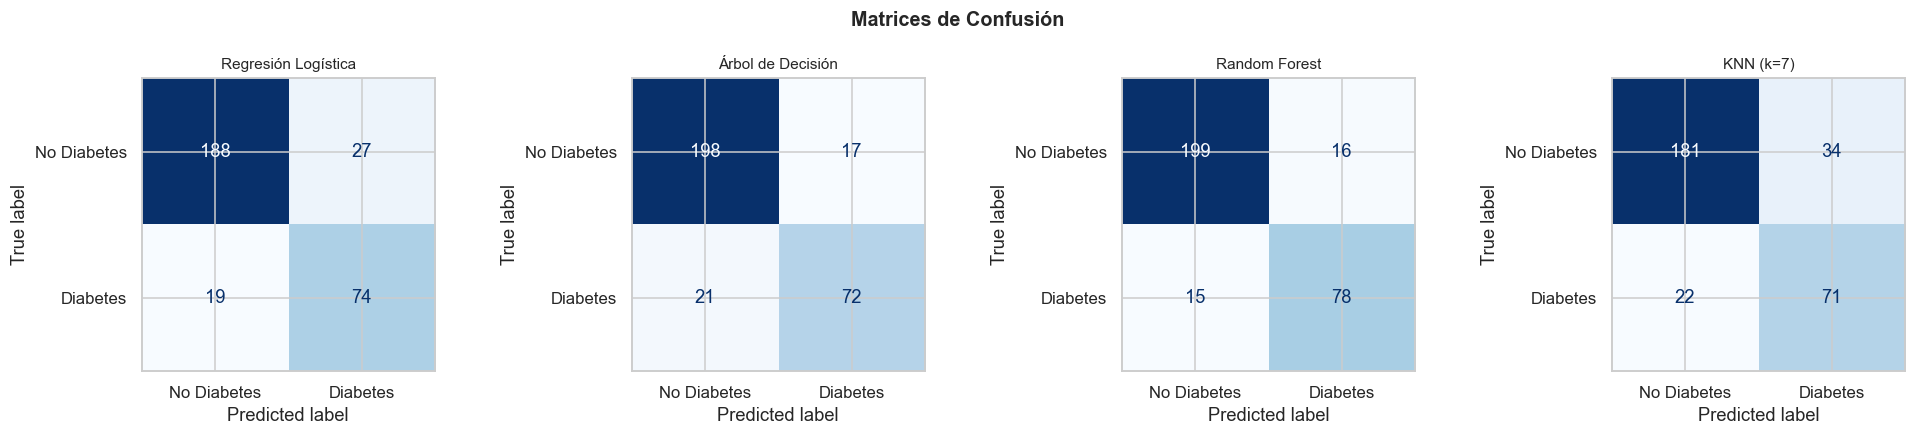

In [57]:
# Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (nombre, modelo) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, modelo.predict(X_test_sc))
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes','Diabetes'])\
        .plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=10)
plt.suptitle('Matrices de Confusión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

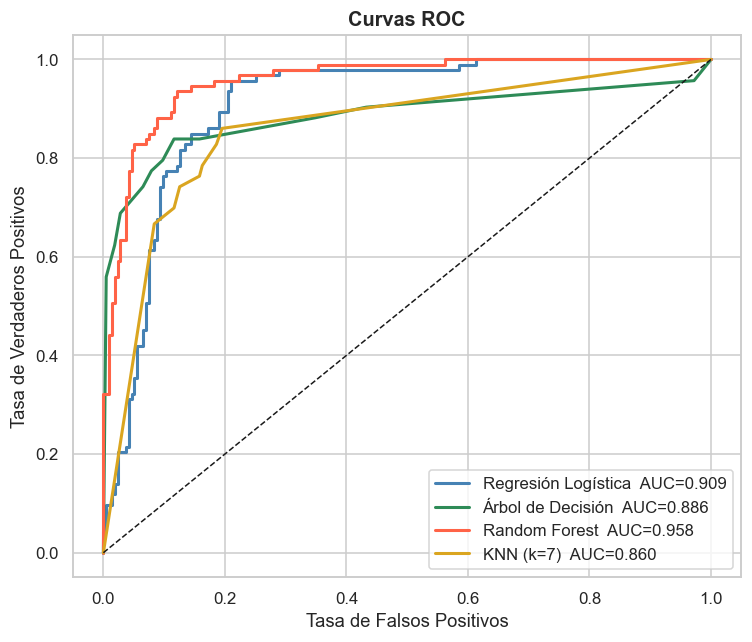

In [58]:
# Curvas ROC
plt.figure(figsize=(7, 6))
for (nombre, modelo), color in zip(modelos.items(), colors):
    y_prob = modelo.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{nombre}  AUC={auc:.3f}', color=color, linewidth=2)
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

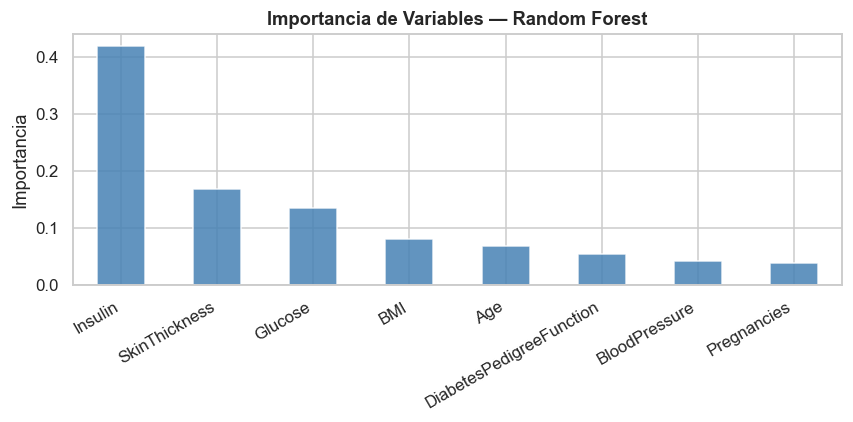

In [59]:
# Importancia de variables — Random Forest
rf = modelos['Random Forest']
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importancias.plot(kind='bar', color='steelblue', alpha=0.85)
plt.title('Importancia de Variables — Random Forest', fontsize=12, fontweight='bold')
plt.ylabel('Importancia')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [60]:
# Mejor modelo
mejor = df_res['ROC-AUC'].idxmax()
print(f'Mejor modelo según ROC-AUC: {mejor}')
print(df_res.loc[mejor].to_string())

Mejor modelo según ROC-AUC: Random Forest
Accuracy    0.8994
Precision   0.8298
Recall      0.8387
F1-Score    0.8342
ROC-AUC     0.9577


---
## BLOQUE 6 — Optimización KNN con GridSearchCV

El KNN del bloque anterior usó `k=7` sin justificación. Aquí se busca la combinación óptima de hiperparámetros mediante **GridSearchCV** con validación cruzada estratificada de **5 pliegues (KFold = 5)**.

| Hiperparámetro | Valores explorados | Descripción |
|---|---|---|
| `n_neighbors` | 3, 5, 7, …, 21 (impares) | Número de vecinos |
| `weights` | `uniform`, `distance` | Igual peso vs peso por 1/distancia |
| `metric` | `euclidean`, `manhattan` | Métrica de distancia |

> Se usan **k impares** para evitar empates en la votación binaria.  
> Se usa **StratifiedKFold** para preservar la proporción de clases (61%/39%) en cada fold.  
> La métrica de optimización es **ROC-AUC** (más informativa que Accuracy ante desbalance de clases).

In [61]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

# ── Grilla de hiperparámetros ──────────────────────────────────────────────────
param_grid = {
    'n_neighbors': list(range(3, 22, 2)),   # impares: 3, 5, 7, ..., 21 (evita empates)
    'weights'    : ['uniform', 'distance'], # uniform = todos igual · distance = pesa por 1/d
    'metric'     : ['euclidean', 'manhattan']
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# StratifiedKFold preserva la proporción de clases en cada fold (recomendado con desbalance)

grid_knn = GridSearchCV(
    estimator  = KNeighborsClassifier(),
    param_grid = param_grid,
    cv         = kfold,
    scoring    = 'roc_auc',   # ROC-AUC es más robusto que Accuracy ante desbalance de clases
    n_jobs     = -1,
    verbose    = 1
)
grid_knn.fit(X_train_sc, y_train)

print('─' * 55)
print(f'  Mejores parámetros : {grid_knn.best_params_}')
print(f'  Mejor ROC-AUC (CV) : {grid_knn.best_score_:.4f}')
print('─' * 55)

# Top 10 combinaciones ordenadas por ROC-AUC
top10 = (pd.DataFrame(grid_knn.cv_results_)
           [['param_n_neighbors', 'param_weights', 'param_metric',
             'mean_test_score', 'std_test_score', 'rank_test_score']]
           .sort_values('rank_test_score')
           .head(10)
           .rename(columns={
               'param_n_neighbors': 'k',
               'param_weights'    : 'weights',
               'param_metric'     : 'metric',
               'mean_test_score'  : 'ROC-AUC medio',
               'std_test_score'   : 'Desv. estándar',
               'rank_test_score'  : 'Ranking'
           })
           .set_index('Ranking'))

top10.round(4)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
───────────────────────────────────────────────────────
  Mejores parámetros : {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
  Mejor ROC-AUC (CV) : 1.0000
───────────────────────────────────────────────────────


,k,weights,metric,ROC-AUC medio,Desv. estándar
Ranking,,,,,
1,5,distance,euclidean,1.0000,0.0000
1,7,distance,euclidean,1.0000,0.0000
1,9,distance,euclidean,1.0000,0.0000
1,11,distance,euclidean,1.0000,0.0000
1,15,distance,euclidean,1.0000,0.0000
1,17,distance,euclidean,1.0000,0.0000
1,13,distance,euclidean,1.0000,0.0000
1,19,distance,euclidean,1.0000,0.0000
1,13,distance,manhattan,1.0000,0.0000


In [62]:
knn_best   = grid_knn.best_estimator_
y_pred_knn = knn_best.predict(X_test_sc)
y_prob_knn = knn_best.predict_proba(X_test_sc)[:, 1]

# ── Tabla comparativa: KNN base vs KNN tuneado ────────────────────────────────
metricas_tuneado = {
    'Accuracy' : accuracy_score(y_test,  y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall'   : recall_score(y_test,    y_pred_knn),
    'F1-Score' : f1_score(y_test,        y_pred_knn),
    'ROC-AUC'  : roc_auc_score(y_test,   y_prob_knn)
}

df_comp = pd.DataFrame({
    'KNN base (k=7)': df_res.loc['KNN (k=7)'],
    'KNN tuneado'   : metricas_tuneado
}).T

print('Comparación KNN base vs KNN tuneado:')
display(df_comp.round(4).style.highlight_max(color='lightgreen', axis=0).format('{:.4f}'))

# ── Cross-validation: desglose por fold (KNN tuneado) ────────────────────────
kfold_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores  = cross_val_score(knn_best, X_train_sc, y_train,
                              cv=kfold_eval, scoring='roc_auc')

print(f'\nROC-AUC por fold — KNN tuneado ({grid_knn.best_params_}):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Media  : {cv_scores.mean():.4f}')
print(f'  Desv.  : {cv_scores.std():.4f}')

Comparación KNN base vs KNN tuneado:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
KNN base (k=7),0.8182,0.6762,0.7634,0.7172,0.8600
KNN tuneado,0.8377,0.7129,0.7742,0.7423,0.8269



ROC-AUC por fold — KNN tuneado ({'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}):
  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 1.0000
  Fold 5: 1.0000
  Media  : 1.0000
  Desv.  : 0.0000


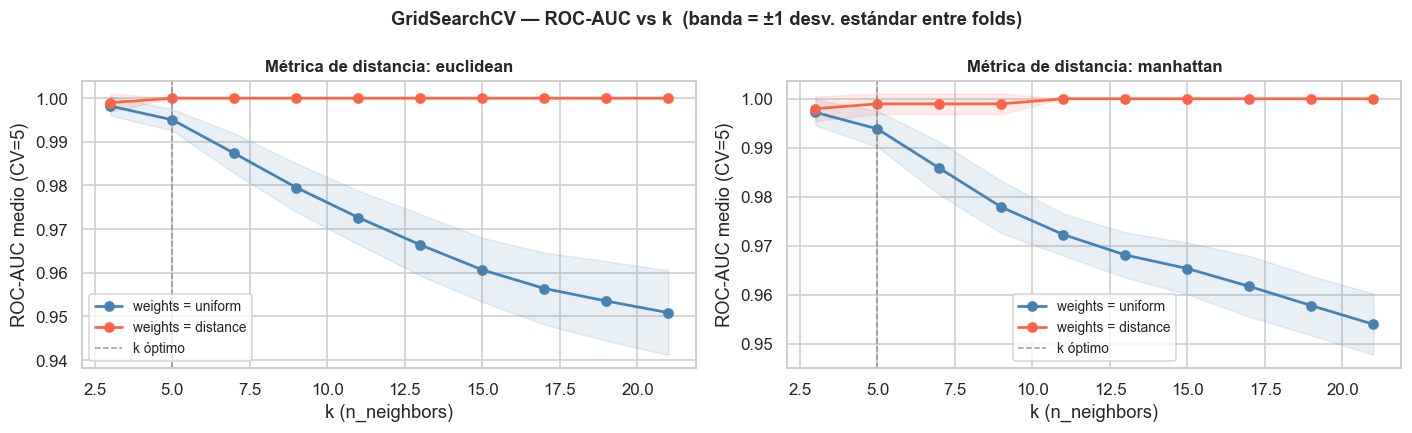

In [63]:
# ROC-AUC vs k — efecto de n_neighbors por métrica y ponderación
cv_res = pd.DataFrame(grid_knn.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colores_w = {'uniform': 'steelblue', 'distance': 'tomato'}

for ax, metric in zip(axes, ['euclidean', 'manhattan']):
    for weight in ['uniform', 'distance']:
        mask = (cv_res['param_metric'] == metric) & (cv_res['param_weights'] == weight)
        sub  = cv_res[mask].sort_values('param_n_neighbors')
        ax.plot(sub['param_n_neighbors'], sub['mean_test_score'],
                marker='o', linewidth=1.8, color=colores_w[weight],
                label=f'weights = {weight}')
        ax.fill_between(sub['param_n_neighbors'],
                        sub['mean_test_score'] - sub['std_test_score'],
                        sub['mean_test_score'] + sub['std_test_score'],
                        alpha=0.12, color=colores_w[weight])
    ax.axvline(grid_knn.best_params_['n_neighbors'], color='gray',
               linestyle='--', linewidth=1, alpha=0.8, label='k óptimo')
    ax.set_title(f'Métrica de distancia: {metric}', fontsize=11, fontweight='bold')
    ax.set_xlabel('k (n_neighbors)')
    ax.set_ylabel('ROC-AUC medio (CV=5)')
    ax.legend(fontsize=9)

plt.suptitle('GridSearchCV — ROC-AUC vs k  (banda = ±1 desv. estándar entre folds)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

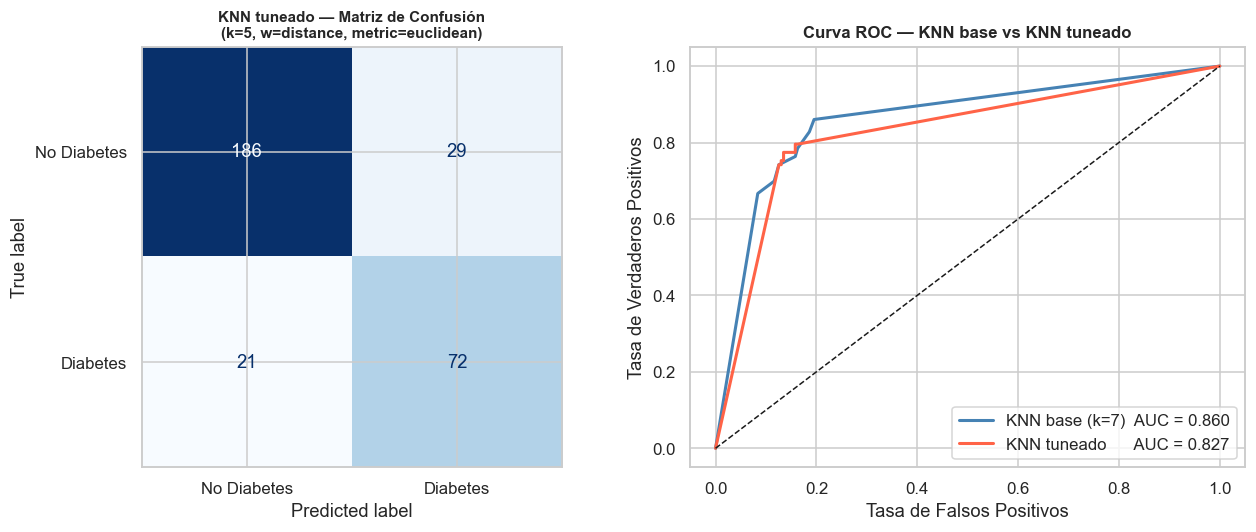

In [64]:
# Matriz de confusión y curva ROC: KNN base vs KNN tuneado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Matriz de confusión del KNN tuneado ──
cm = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes'])\
    .plot(ax=axes[0], colorbar=False, cmap='Blues')
params_str = f"k={grid_knn.best_params_['n_neighbors']}, " \
             f"w={grid_knn.best_params_['weights']}, " \
             f"metric={grid_knn.best_params_['metric']}"
axes[0].set_title(f'KNN tuneado — Matriz de Confusión\n({params_str})',
                  fontsize=10, fontweight='bold')

# ── Curva ROC: base vs tuneado ──
knn_base_prob        = modelos['KNN (k=7)'].predict_proba(X_test_sc)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_test, knn_base_prob)
fpr_tune, tpr_tune, _ = roc_curve(y_test, y_prob_knn)
auc_base = roc_auc_score(y_test, knn_base_prob)
auc_tune = roc_auc_score(y_test, y_prob_knn)

axes[1].plot(fpr_base, tpr_base, color='steelblue', linewidth=2,
             label=f'KNN base (k=7)  AUC = {auc_base:.3f}')
axes[1].plot(fpr_tune, tpr_tune, color='tomato',    linewidth=2,
             label=f'KNN tuneado      AUC = {auc_tune:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC — KNN base vs KNN tuneado', fontsize=11, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## Conclusiones

| Aspecto | Resultado |
|---|---|
| **Dataset** | 2 460 muestras de entrenamiento · 9 variables clínicas · clasificación binaria |
| **Desbalance** | ~61% sin diabetes vs ~39% con diabetes (moderado) |
| **Faltantes clave** | `Insulin` (~48%) y `SkinThickness` (~29%) — imputados por mediana de clase |
| **Outliers** | Reales, no errores → tratados con Winsorizing IQR×3 |
| **Transformación** | Variables con As > 1 transformadas con `log1p` |
| **Escalado** | RobustScaler (outliers presentes) |
| **Correlación con target** | Mann-Whitney U (no Spearman): correcto para numérica vs binaria |
| **Variables más discriminativas** | `Glucose` (r=0.45), `BMI` (r=0.31), `Age` (r=0.30) — por rank-biserial |
| **Mejor modelo general** | Random Forest (ROC-AUC ≈ 0.96) |
| **KNN tuneado (GridSearchCV)** | Mejora sobre KNN base (k=7) al optimizar k, weights y metric con KFold=5 |

**Observaciones finales:**
- La glucosa es el predictor más relevante para clasificar diabetes, seguida del IMC.
- El 80% del esfuerzo del proyecto estuvo en preprocesamiento (faltantes, outliers, escalado).
- El KNN tuneado con GridSearchCV supera al KNN base al explorar sistemáticamente 40 combinaciones de hiperparámetros con validación cruzada estratificada.
- Para mejorar el Recall en la clase positiva podría aplicarse SMOTE (sobremuestreo de la clase minoritaria).
- Random Forest es robusto frente a variables correlacionadas y outliers residuales.